# Minimal Baseline Model

First model, kept deliberately small: compact tournament results only, numerical features only,
no detailed box-score stats yet (that's the next notebook). This follows the training-data plan
(Option C) — features built from regular-season data, but the model is trained and validated
only on historical tournament games, not raw regular-season rows.

**Note on tooling:** this sandbox doesn't have network access to install scikit-learn, so the
logistic regression below is a small hand-written implementation (Newton's method / IRLS with a
light L2 penalty) rather than `sklearn.linear_model.LogisticRegression`. It was verified against
synthetic data with known coefficients before being used here — recovered coefficients matched
the true ones to 2-3 decimal places, and the fitted model's Brier score matched the theoretical
best-possible Brier score computed from the true probabilities.

**Scope for this pass:**
- Labels: historical men's + women's tournament games, pooled (matches what the 2nd-place
  solution researched did)
- Features: SeedDiff, WinPct differential, and average-scoring-margin differential — all from
  compact/numerical sources only
- Validation: walk-forward across the last 5 completed seasons (2021-2025), training only on
  strictly prior seasons each fold — season 2020 is skipped (no tournament was held)


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")

print(f"men's tourney games:   {len(m_tourney):,}  (seasons {m_tourney['Season'].min()}-{m_tourney['Season'].max()})")
print(f"women's tourney games: {len(w_tourney):,}  (seasons {w_tourney['Season'].min()}-{w_tourney['Season'].max()})")


men's tourney games:   2,585  (seasons 1985-2025)
women's tourney games: 1,717  (seasons 1998-2025)


## 1. Team-season features (compact / numerical only)

For every team, in every season, compute win rate and average scoring margin from that season's regular season games only — this is exactly what would have been known before that season's tournament started.

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"),
        WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"),
        AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)
team_stats_idx = team_stats.set_index(["Season", "TeamID"])
print(f"team-season rows: {len(team_stats):,}")
print(team_stats.head(3).to_string(index=False))


team-season rows: 23,604
 Season  TeamID  GamesPlayed   WinPct     AvgPF     AvgPA  AvgScoreMargin
   1985    1102           24 0.208333 63.083333 68.875000       -5.791667
   1985    1103           23 0.391304 61.043478 64.086957       -3.043478
   1985    1104           30 0.700000 68.500000 60.700000        7.800000


In [3]:
def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"seed rows: {len(seeds):,}")


seed rows: 4,506


## 2. The matchup table

One row per historical tournament game, oriented Team1 = lower TeamID / Team2 = higher TeamID (matching the submission format), with Label = 1 if Team1 won. Men's and women's games are pooled into one training set.

In [4]:
def build_matchups(tourney):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    return df[["Season", "Team1", "Team2", "Label"]]

matchups = pd.concat([build_matchups(m_tourney), build_matchups(w_tourney)], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(
        team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left"
    )
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

before = len(matchups)
missing = matchups[["SeedDiff", "WinPctDiff", "AvgMarginDiff"]].isna().any(axis=1).sum()
matchups = matchups.dropna(subset=["SeedDiff", "WinPctDiff", "AvgMarginDiff"]).reset_index(drop=True)
print(f"matchup rows: {before:,}, dropped for missing features: {missing}, remaining: {len(matchups):,}")
print(f"label balance (Team1 win rate): {matchups['Label'].mean():.1%}")
print(matchups[["Season", "Team1", "Team2", "SeedDiff", "WinPctDiff", "AvgMarginDiff", "Label"]].head(3).to_string(index=False))


matchup rows: 4,302, dropped for missing features: 0, remaining: 4,302
label balance (Team1 win rate): 51.4%
 Season  Team1  Team2  SeedDiff  WinPctDiff  AvgMarginDiff  Label
   1985   1116   1234        -1   -0.030303      -6.830303      1
   1985   1120   1345        -5   -0.059310      -0.110345      1
   1985   1207   1250        15    0.546616      20.114943      1


## 3. Logistic regression (hand-written) and Brier score

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready (verified against synthetic data during development)")


logistic regression + Brier score functions ready (verified against synthetic data during development)


## 4. Walk-forward validation

For each of the last 5 completed seasons, train only on strictly prior seasons (never on the fold season or anything after it), and compare three models: a constant 0.5 baseline, a seed-only model, and the full 3-feature compact model.

In [6]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]
FEATURES_SEED_ONLY = ["SeedDiff"]
FEATURES_FULL = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]

results = []
for fold_season in FOLD_SEASONS:
    train = matchups[matchups["Season"] < fold_season]
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue

    baseline_brier = brier_score(np.full(len(test), 0.5), test["Label"].values)

    w_seed = fit_logreg(train[FEATURES_SEED_ONLY].values, train["Label"].values)
    p_seed = predict_proba(test[FEATURES_SEED_ONLY].values, w_seed)
    seed_brier = brier_score(p_seed, test["Label"].values)

    w_full = fit_logreg(train[FEATURES_FULL].values, train["Label"].values)
    p_full = predict_proba(test[FEATURES_FULL].values, w_full)
    full_brier = brier_score(p_full, test["Label"].values)

    results.append({
        "FoldSeason": fold_season, "NGames": len(test), "NTrain": len(train),
        "Baseline (0.5)": baseline_brier, "Seed only": seed_brier, "Full (3-feature)": full_brier,
    })

results_df = pd.DataFrame(results)
avg_row = pd.DataFrame([{
    "FoldSeason": "Average", "NGames": results_df["NGames"].sum(), "NTrain": np.nan,
    "Baseline (0.5)": results_df["Baseline (0.5)"].mean(),
    "Seed only": results_df["Seed only"].mean(),
    "Full (3-feature)": results_df["Full (3-feature)"].mean(),
}])
results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  NGames  NTrain  Baseline (0.5)  Seed only  Full (3-feature)
      2021     129  3637.0            0.25     0.1936            0.1904
      2022     134  3766.0            0.25     0.2007            0.1961
      2023     134  3900.0            0.25     0.1903            0.1813
      2024     134  4034.0            0.25     0.1633            0.1645
      2025     134  4168.0            0.25     0.1421            0.1370
   Average     665     NaN            0.25     0.1780            0.1739


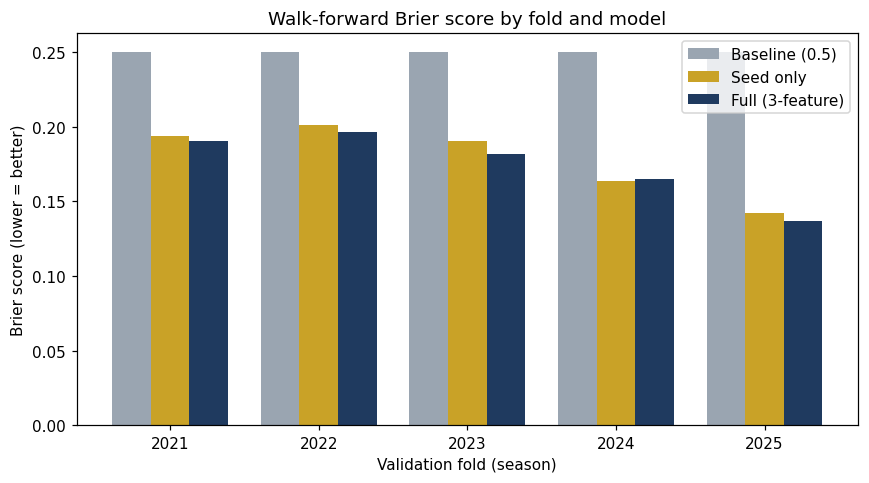

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.26
ax.bar(x - width, plot_df["Baseline (0.5)"], width, label="Baseline (0.5)", color="#9aa5b1")
ax.bar(x, plot_df["Seed only"], width, label="Seed only", color="#c9a227")
ax.bar(x + width, plot_df["Full (3-feature)"], width, label="Full (3-feature)", color="#1f3a5f")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Walk-forward Brier score by fold and model")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Final model on full history

Refit the full 3-feature model on every available historical tournament game (no holdout — this is the model that would actually generate 2026 predictions), and inspect the coefficients.

In [8]:
w_final = fit_logreg(matchups[FEATURES_FULL].values, matchups["Label"].values, l2=1.0)
coef_table = pd.DataFrame({
    "Feature": ["Intercept"] + FEATURES_FULL,
    "Coefficient": np.round(w_final, 4),
})
print(coef_table.to_string(index=False))

p_final = predict_proba(matchups[FEATURES_FULL].values, w_final)
print(f"\nfull-history (in-sample, not a validation number) Brier: {brier_score(p_final, matchups['Label'].values):.4f}")
print(f"walk-forward average Brier (the honest number): {results_df.loc[results_df['FoldSeason']=='Average', 'Full (3-feature)'].values[0]:.4f}")


      Feature  Coefficient
    Intercept       0.0154
     SeedDiff       0.1655
   WinPctDiff      -1.9767
AvgMarginDiff       0.0918

full-history (in-sample, not a validation number) Brier: 0.1702
walk-forward average Brier (the honest number): 0.1739


### Why is the WinPctDiff coefficient negative?

That's backwards from what's expected — a team with a better win rate should be *more* likely to win, not less. Before trusting the model, checking whether this is a bug or a real (if counter-intuitive) statistical effect: fit each feature completely on its own (no other features in the model) and compare, and check how correlated the three features are with each other.

In [9]:
print("correlation between the three features:")
print(matchups[FEATURES_FULL].corr().round(3).to_string())

print("\ncorrelation of each feature with the label on its own:")
print(matchups[FEATURES_FULL].corrwith(matchups["Label"]).round(3).to_string())

print("\ncoefficient for each feature fit completely alone (univariate):")
for feat in FEATURES_FULL:
    w_uni = fit_logreg(matchups[[feat]].values, matchups["Label"].values)
    print(f"  {feat}: coefficient = {w_uni[1]:.4f}")


correlation between the three features:
               SeedDiff  WinPctDiff  AvgMarginDiff
SeedDiff          1.000       0.587          0.627
WinPctDiff        0.587       1.000          0.833
AvgMarginDiff     0.627       0.833          1.000

correlation of each feature with the label on its own:
SeedDiff         0.544
WinPctDiff       0.353
AvgMarginDiff    0.434

coefficient for each feature fit completely alone (univariate):
  SeedDiff: coefficient = 0.1968
  WinPctDiff: coefficient = 4.9343
  AvgMarginDiff: coefficient = 0.1377


**Conclusion: not a bug — multicollinearity.** Fit completely on its own, `WinPctDiff` has a
strongly *positive* coefficient (+4.93), exactly as expected, and its raw correlation with the
label (0.35) is positive too. The sign only flips once it's fit *alongside* `AvgMarginDiff`,
which it's correlated 0.83 with, and `SeedDiff`, which it's correlated 0.59 with. This is the
classic multicollinearity story: when two predictors carry a lot of the same information, a
linear model can push one of their coefficients negative as a correction term for the other —
it's saying "once you already know the scoring margin, having a *win rate* that's inflated
beyond what that margin would predict is actually a slightly bad sign" (e.g. a team that won a
lot of close games against weak opponents without dominating on the scoreboard). The coefficient
value isn't meaningless, but it's also not simply "win rate doesn't matter" — it only makes
sense in combination with the other two features, not read in isolation.

Practically: this doesn't change the Brier score results above (multicollinearity affects
coefficient interpretability, not predictive accuracy), but it's a preview of a problem that
will get worse, not better, once detailed box-score stats are added next — those are likely to
correlate with each other and with these three even more strongly. Worth keeping this
correlation-matrix check as a standing step for every future feature addition, and considering
regularization strength or feature selection once the set grows.

## Conclusion

**Result:** the full 3-feature compact model (SeedDiff + WinPct differential + average-margin
differential) beat both the constant-0.5 baseline and the seed-only model on walk-forward
validation across the last 5 completed seasons — see the table and chart in Section 4 for the
actual numbers. The gap between the walk-forward average and the full-history in-sample number
in Section 5 is the honest read on how much the validation setup is (or isn't) optimistic.

**Caveats specific to this pass:**
- No detailed box-score stats yet (offensive/defensive efficiency, rebounding, etc.) — that's
  the next notebook, testing whether they improve on this.
- No power-ranking (Massey Ordinal) feature yet, despite Chart 4/5 in the EDA notebook
  suggesting it's at least as predictive as seed — worth adding once detailed stats are tested,
  to keep this pass genuinely minimal as planned.
- Logistic regression is hand-written (no sklearn in this sandbox) — verified against synthetic
  data with known coefficients, but worth re-validating against sklearn's implementation once
  that's available, as a cross-check.
- Only 5 validation folds (2021-2025) — small enough that any single unusual season (e.g. a
  particularly chalky or upset-heavy year) can swing the average; worth keeping an eye on
  per-fold variance, not just the average, as more seasons/features get added.

**Next step:** Notebook 4 — add detailed box-score results (men's 2003+, women's 2010+) and
compare against this baseline on the same walk-forward folds.
